# Autoencoder Convolutional Neural Network
An autoencoder basically is a feature extractor for unlabeled images to then feed into a clustering algorithm like K-Means or DBScan

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

I0000 00:00:1775930580.721456   23340 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775930580.771868   23340 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775930582.282794   23340 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### MODEL

In [20]:
def build_autoencoder(input_shape=(2, 8575)):
    input_img = layers.Input(shape=input_shape)

    # ENCODER
    # keras logistics
    x = layers.Permute((2, 1))(input_img) 

    # hidden layers
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2, padding='same')(x)
    x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2, padding='same')(x)
    x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
    
    # final encoded layer
    encoded = layers.Flatten()(x)
    latent_dim = 8 # Final params
    latent_space = layers.Dense(latent_dim, name="latent_space")(encoded)

    # DECODER 
    x = layers.Dense(2144 * 8)(latent_space)
    x = layers.Reshape((2144, 8))(x)
    
    x = layers.Conv1DTranspose(8, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1DTranspose(16, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)

    # final decoded layer
    decoded = layers.Conv1D(2, 3, activation='linear', padding='same')(x)
    
    decoded = layers.Cropping1D(cropping=(0, 1))(decoded)
    output = layers.Permute((2, 1))(x)
    output = layers.Permute((2, 1))(decoded)

    # loss comparison
    autoencoder = models.Model(input_img, output)
    autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae', 'cosine_similarity'])
    
    return autoencoder

# Initialize the model
model = build_autoencoder()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2, 8575)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_3 (Permute)             │ (None, 8575, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 8575, 64)       │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4288, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 4288, 32)       │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 2144, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 2144, 16)       │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 34304)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │       274,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17152)          │       154,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 2144, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 2144, 8)        │           200 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 4288, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_3              │ (None, 4288, 16)       │           400 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_3 (UpSampling1D)  │ (None, 8576, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 8576, 2)        │            98 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping1d_1 (Cropping1D)       │ (None, 8575, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_5 (Permute)             │ (None, 2, 8575)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437,682 (1.67 MB)

 Trainable params: 437,682 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

### PREPROCESSING

In [27]:
data = np.load('processed_spectra.npy')

print(f"Original shape: {data.shape}")

Original shape: (10188, 2, 8575)


In [45]:
# for reproduction
np.random.seed(42)
tf.random.set_seed(42)

# train/test splitting
x_train_raw, x_val_raw = train_test_split(data, test_size=0.2, random_state=42)

# normalizing
x_train = (x_train_raw - x_train_raw.min(axis=-1, keepdims=True)) / \
          (x_train_raw.max(axis=-1, keepdims=True) - x_train_raw.min(axis=-1, keepdims=True))

x_val = (x_val_raw - x_val_raw.min(axis=-1, keepdims=True)) / \
        (x_val_raw.max(axis=-1, keepdims=True) - x_val_raw.min(axis=-1, keepdims=True))

### TRAINING
Because we're doing unsupervised machine learning right now, we're comparing our finds to the input itself.

In [46]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="./logs")

history = model.fit(
    x_train, x_train,
    epochs=50, 
    batch_size=32,
    validation_data=(x_val, x_val),
    shuffle=True,
    callbacks=[tensorboard_callback]
)

Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - cosine_similarity: 0.5098 - loss: 0.0086 - mae: 0.0450 - val_cosine_similarity: 0.5241 - val_loss: 0.0015 - val_mae: 0.0236
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - cosine_similarity: 0.5291 - loss: 0.0015 - mae: 0.0218 - val_cosine_similarity: 0.5349 - val_loss: 0.0013 - val_mae: 0.0201
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - cosine_similarity: 0.5400 - loss: 0.0012 - mae: 0.0191 - val_cosine_similarity: 0.5452 - val_loss: 0.0011 - val_mae: 0.0180
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - cosine_similarity: 0.5495 - loss: 0.0011 - mae: 0.0174 - val_cosine_similarity: 0.5538 - val_loss: 9.9066e-04 - val_mae: 0.0169
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - cosine_similarity: 0.5568 - loss: 0.0010 - mae: 0.0163 - val_cosine_similarity: 0.5626 - val_loss: 8.9059e-04 - val_mae: 0.0154
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - cosine_similarity: 0.5635 - loss: 9.2687e

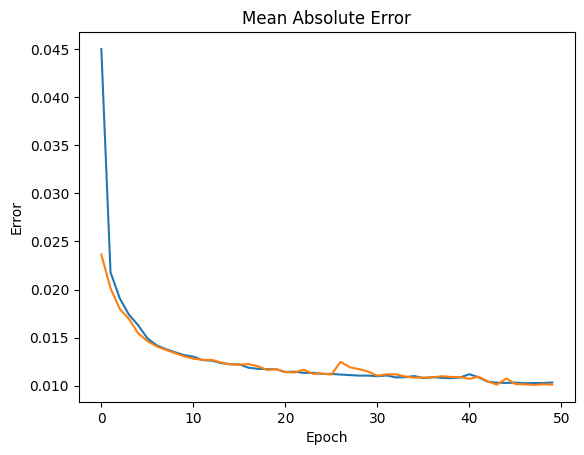

In [56]:
def plot_history(history):
    plt.plot(history.history['mae'], label='train')
    plt.plot(history.history['val_mae'], label='val')
    plt.title('Mean Absolute Error')
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.show()

plot_history(history)

In [ ]:
encoder = models.Model(inputs=model.input, outputs=model.get_layer("latent_space").output)
star_features = encoder.predict(x_train) 

from sklearn.cluster import KMeans

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(star_features)

255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


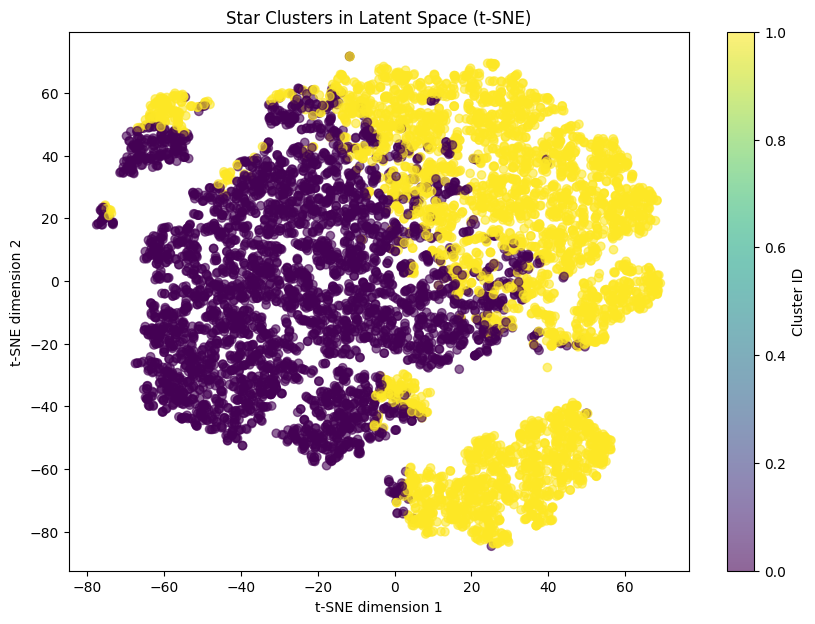

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reducing dimensions for 2D plotting
tsne = TSNE(n_components=2, random_state=42)
star_2d = tsne.fit_transform(star_features)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(star_2d[:, 0], star_2d[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title("Star Clusters")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.show()

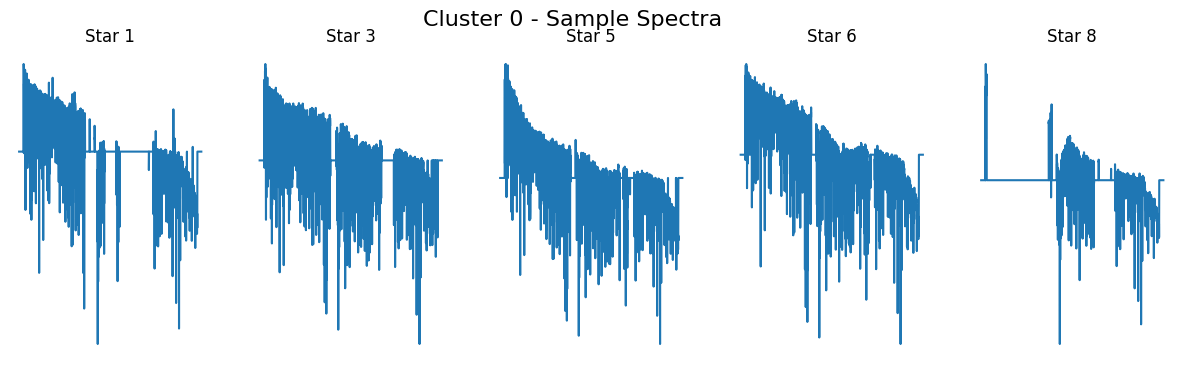

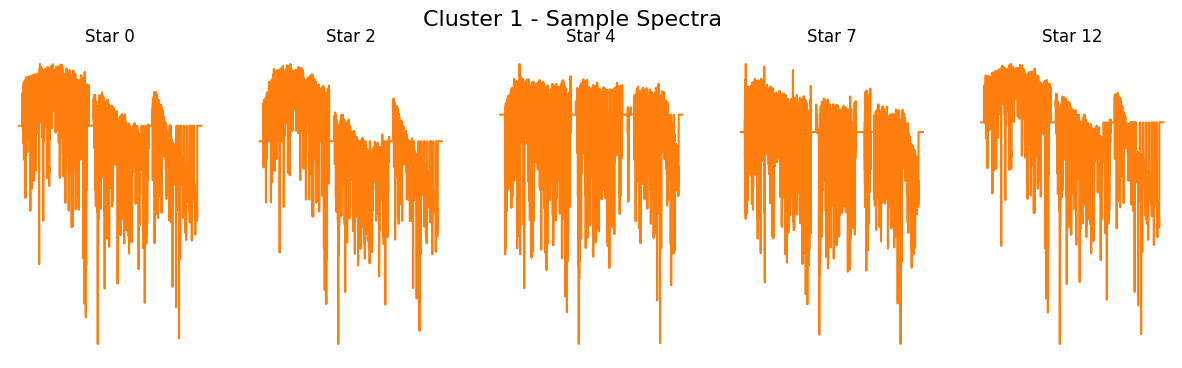

In [ ]:
def inspect_clusters(data, cluster_labels, num_samples=5):
    for cluster_id in [0, 1]:
        indices = np.where(cluster_labels == cluster_id)[0]
        plt.figure(figsize=(15, 4))
        plt.suptitle(f"Cluster {cluster_id} - Sample Spectra", fontsize=16)
        
        for i in range(min(num_samples, len(indices))):
            plt.subplot(1, num_samples, i + 1)
            idx = indices[i]
            # Plotting the flux[0]
            plt.plot(data[idx, 0, :], color='C'+str(cluster_id))
            plt.axis('off')
            plt.title(f"Star {idx}")
        plt.show()

inspect_clusters(x_train, clusters)